In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
import matplotlib.pyplot as plt

import kind
import ex_duffing
import util_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', '../../data/dreamer',
        '--file_name', 'duffing',
        '--data_nsample', '8000',
        '--feature_ndim', '4',
        '--target_ndim', '2',
        '--data_train_size', '0.6',

        '--lookback_nsample', '384',
        '--forecast_nsample', '192',

        '--batch_size', '64',
        '--nepoch', '50',
        '--patience', '10',
        '--checkpoints', '../../models/dreamer',

        '--seg_nsample_stat', '192',
        '--seg_nsample_trans', '192',
        '--fun_stat', '{"sin": 4, "cos": 4}',
        '--fun_trans', '{"data": 12}',
    ]
)

In [3]:
model = kind.model(args)

dataset = ex_duffing.dataset(
    args.file_dir, args.file_name, args.file_ext,
    args.data_nsample,
    (args.data_train_size, args.data_test_size),
    args.batch_size, (args.lookback_nsample, args.forecast_nsample), load_normalized=True)

training = kind.training(model)

In [4]:
model.train()
training.fit(dataset)

>>> training nominal mean >>>
	epoch 1 losses: train=0.251296, valid=0.241392, test=0.241268
	validation loss decreased (inf -> 0.241392), saving model ...
	epoch 2 losses: train=0.114992, valid=0.004914, test=0.004970
	validation loss decreased (0.241392 -> 0.004914), saving model ...
	epoch 3 losses: train=0.001851, valid=0.000863, test=0.000846
	validation loss decreased (0.004914 -> 0.000863), saving model ...
	epoch 4 losses: train=0.000548, valid=0.000354, test=0.000350
	validation loss decreased (0.000863 -> 0.000354), saving model ...
	epoch 5 losses: train=0.000242, valid=0.000143, test=0.000142
	validation loss decreased (0.000354 -> 0.000143), saving model ...
	epoch 6 losses: train=0.000092, valid=0.000051, test=0.000051
	validation loss decreased (0.000143 -> 0.000051), saving model ...
	epoch 7 losses: train=0.000036, valid=0.000025, test=0.000025
	validation loss decreased (0.000051 -> 0.000025), saving model ...
	epoch 8 losses: train=0.000026, valid=0.000027, test=0.00

In [5]:
model.eval()
_, _, data_loader = dataset.load(data_type='nom')

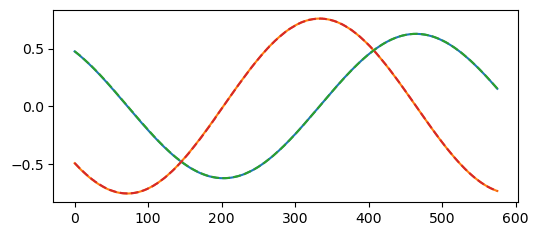

In [6]:
jdata = 2

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]

        plt.figure(figsize=(6,2.5))
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.show()

        break


In [7]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training nominal uncertainty >>>
	epoch 1 losses: train=0.042823, valid=0.035986, test=0.035974
	validation loss decreased (inf -> 0.035986), saving model ...
	epoch 2 losses: train=0.022765, valid=0.020698, test=0.020696
	validation loss decreased (0.035986 -> 0.020698), saving model ...
	epoch 3 losses: train=0.019424, valid=0.017475, test=0.017380
	validation loss decreased (0.020698 -> 0.017475), saving model ...
	epoch 4 losses: train=0.014455, valid=0.012305, test=0.012217
	validation loss decreased (0.017475 -> 0.012305), saving model ...
	epoch 5 losses: train=0.011430, valid=0.010707, test=0.010652
	validation loss decreased (0.012305 -> 0.010707), saving model ...
	epoch 6 losses: train=0.010546, valid=0.010554, test=0.010538
	validation loss decreased (0.010707 -> 0.010554), saving model ...
	epoch 7 losses: train=0.009971, valid=0.009669, test=0.009638
	validation loss decreased (0.010554 -> 0.009669), saving model ...
	epoch 8 losses: train=0.009407, valid=0.009202, te

In [8]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

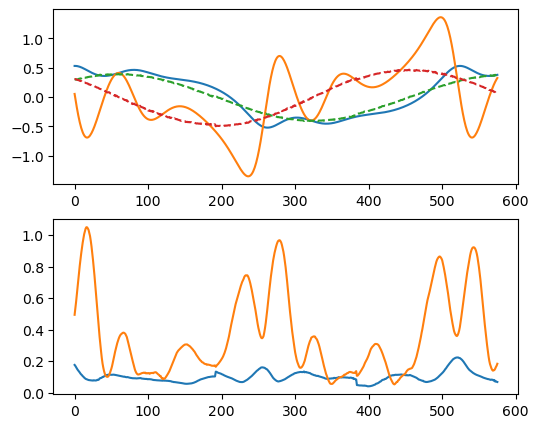

In [9]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]
        stat_u = model_output[2]

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(stat_u[0, :, :2])

        plt.show()

        break


In [10]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion mean >>>
	epoch 1 losses: train=0.251136, valid=0.218879, test=0.218791
	validation loss decreased (inf -> 0.218879), saving model ...
	epoch 2 losses: train=0.188115, valid=0.159111, test=0.159284
	validation loss decreased (0.218879 -> 0.159111), saving model ...
	epoch 3 losses: train=0.104055, valid=0.086224, test=0.086472
	validation loss decreased (0.159111 -> 0.086224), saving model ...
	epoch 4 losses: train=0.063978, valid=0.047622, test=0.047739
	validation loss decreased (0.086224 -> 0.047622), saving model ...
	epoch 5 losses: train=0.033747, valid=0.016026, test=0.016157
	validation loss decreased (0.047622 -> 0.016026), saving model ...
	epoch 6 losses: train=0.010023, valid=0.005038, test=0.005027
	validation loss decreased (0.016026 -> 0.005038), saving model ...
	epoch 7 losses: train=0.004055, valid=0.002525, test=0.002528
	validation loss decreased (0.005038 -> 0.002525), saving model ...
	epoch 8 losses: train=0.002452, valid=0.001998, test=0.

In [11]:
model.eval()
_, _, data_loader = dataset.load(data_type='exc')

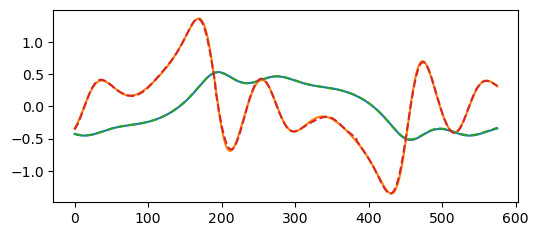

In [12]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[3]

        plt.figure(figsize=(6,2.5))
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.show()

        break

In [13]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion uncertainty >>>
	epoch 1 losses: train=0.021243, valid=0.015622, test=0.015549
	validation loss decreased (inf -> 0.015622), saving model ...
	epoch 2 losses: train=0.015489, valid=0.015564, test=0.015488
	validation loss decreased (0.015622 -> 0.015564), saving model ...
	epoch 3 losses: train=0.015048, valid=0.011833, test=0.011801
	validation loss decreased (0.015564 -> 0.011833), saving model ...
	epoch 4 losses: train=0.007189, valid=0.006856, test=0.006872
	validation loss decreased (0.011833 -> 0.006856), saving model ...
	epoch 5 losses: train=0.006655, valid=0.006785, test=0.006782
	validation loss decreased (0.006856 -> 0.006785), saving model ...
	epoch 6 losses: train=0.006637, valid=0.006720, test=0.006719
	validation loss decreased (0.006785 -> 0.006720), saving model ...
	epoch 7 losses: train=0.006577, valid=0.006382, test=0.006369
	validation loss decreased (0.006720 -> 0.006382), saving model ...
	epoch 8 losses: train=0.006071, valid=0.006042, 

In [14]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

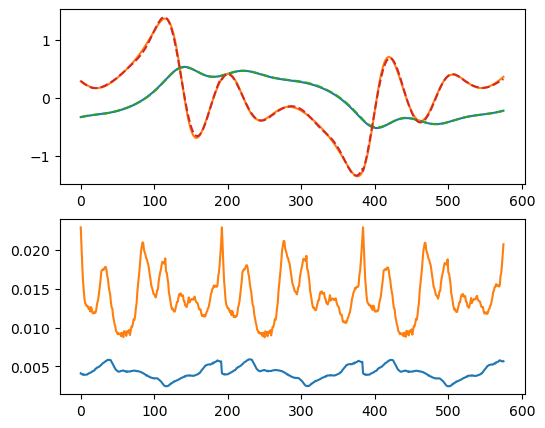

In [15]:
jdata = 3

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        exc = model_output[3]
        exc_u = model_output[4]

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(exc[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(exc_u[0, :, :2])

        plt.show()

        break

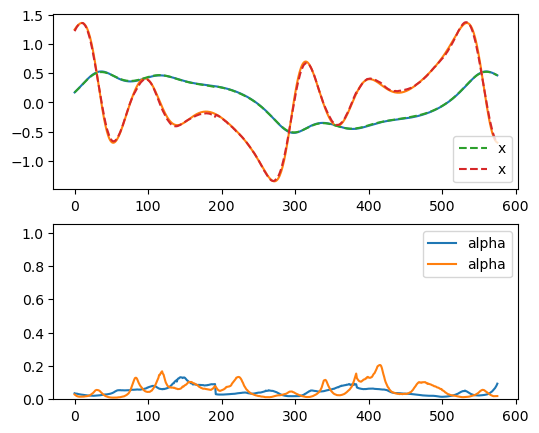

In [27]:
jdata = 11

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        pre = model_output[0]
        alpha = model_output[9]

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(pre[0, :, :2], linestyle='dashed', label='x')
        plt.legend()

        plt.subplot(2,1,2)
        plt.plot(alpha[0, :, :2], label='alpha')
        plt.ylim((0.0, 1.05))
        plt.legend()

        plt.show()

        break